# Introduction to Distributions

*If you haven't read the [Getting Started tutorial](../tutorials/getting_started.ipynb), read it first. This notebook is a more detailed look at distributions, one of ProbPipe's three core types.*

ProbPipe represents probability distributions as Python objects. Each distribution lets you do a subset of the usual things — draw samples, evaluate the density, compute moments, take expectations — through a uniform set of **operations** (**ops**) defined at the package level:

| Op | Meaning |
|---|---|
| `sample(dist, key=..., sample_shape=...)` | Draw samples |
| `log_prob(dist, x)` | Log density (or log mass) at `x` |
| `prob(dist, x)` | Density at `x` — i.e. `exp(log_prob)` |
| `mean(dist)` | `E[X]` |
| `variance(dist)` | `Var[X]` per element |
| `cov(dist)` | Covariance matrix |
| `expectation(dist, f, ...)` | `E[f(X)]` — exact when possible, MC otherwise |
| `condition_on(dist, **observed)` | Bayesian posterior conditioning — covered in the [joint distributions](04_joint_distributions.ipynb) and [external backends](05_external_backends.ipynb) notebooks |

Not every distribution supports every op. An empirical approximation — say, samples from MCMC — can be sampled but has no closed-form density; a Gaussian random function has a density but no finite-dimensional sample. ProbPipe makes these distinctions explicit through **protocols**: lightweight interfaces that say which ops a given distribution supports. Use `isinstance(dist, SupportsX)` to check.

| Protocol | Op | Meaning |
|---|---|---|
| `SupportsSampling` | `sample` | Can draw samples |
| `SupportsLogProb` | `log_prob` / `prob` | Has a density or mass function |
| `SupportsMean` | `mean` | Can compute its mean |
| `SupportsVariance` | `variance` | Can compute its variance |
| `SupportsCovariance` | `cov` | Can compute its covariance matrix |
| `SupportsConditioning` | `condition_on` | Has a fast built-in `condition_on` path (e.g., closed-form or amortized) |
| `SupportsExpectation` | `expectation` | Supports `E[f(X)]` (exact or approximate) |

Each op checks the relevant protocol before dispatching, so calling `log_prob` on something that doesn't support it raises a clear `TypeError` instead of silently returning garbage.

In [1]:
import warnings
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (Normal, Beta, Gamma, Exponential, Bernoulli, Poisson,
                      MultivariateNormal, Dirichlet, Categorical,
                      RecordEmpiricalDistribution, KDEDistribution,
                      BootstrapDistribution, BootstrapReplicateDistribution,
                      sample, log_prob, prob, mean, variance, cov, expectation,
                      from_distribution)
from probpipe.core.protocols import (SupportsSampling, SupportsLogProb,
                                     SupportsMean, SupportsVariance,
                                     SupportsCovariance, SupportsExpectation)

# TFP sampling occasionally requests float64 internally; JAX's default
# x64-disabled mode silently downgrades to float32 and emits a UserWarning.
# Silence the noise — the downgrade is harmless for this tutorial.
warnings.filterwarnings("ignore", message=r".*Explicitly requested dtype float64.*",
                        category=UserWarning)

## 1. Common Distributions

There are few common flavors of distributions. We'll cover the following three in this section:

- **Univariate parametric** — standard exponential and other parametric families (`Normal`, `Beta`, `Gamma`, `Poisson`, `Bernoulli`, ...).
- **Multivariate parametric** — joint distributions over correlated dimensions (`MultivariateNormal`, `Dirichlet`, ...). 
- **Sampling distributions** — distributions defined by samples or bootstrap procedures (`EmpiricalDistribution`, `BootstrapDistribution`, `BootstrapReplicateDistribution`).

The other common flavors are covered elsewhere:
- **Joint distributions** - structured distributions with named components (`ProductDistribution`, `SequentialJointDistribution`,
`JointGaussian`, ...). See [Joint Distributions](04_joint_distributions.ipynb) for more.
- **Models** - distributions meant to represent probabilistic models. See the [Flexible inference tutorial](../tutorials/flexible_inference.ipynb) for more. 

Every construction requires a `name=` argument — the name propagates through ops and is useful for provenance and diagnostics. Each distribution also exposes a `.support` constraint that the converter registry uses to guard cross-family conversions; you can also inspect it yourself to sanity-check a model.

### Univariate parametric families

These have scalar `event_shape=()`. The standard constructors take familiar parameters:

In [2]:
n = Normal(loc=2.0, scale=0.5, name="n")
b = Beta(alpha=2.0, beta=5.0, name="b")
g = Gamma(concentration=3.0, rate=1.0, name="g")

for dist in [n, b, g, Poisson(rate=3.0, name="p"), Bernoulli(probs=0.5, name="coin")]:
    print(f"  {type(dist).__name__:10s} event_shape={dist.event_shape}, support={dist.support}")

  Normal     event_shape=(), support=real
  Beta       event_shape=(), support=unit_interval
  Gamma      event_shape=(), support=positive
  Poisson    event_shape=(), support=non_negative_integer
  Bernoulli  event_shape=(), support=boolean


### Multivariate parametric families

`MultivariateNormal` takes a covariance (`cov=`) or lower-triangular Cholesky factor (`scale_tril=`); `Dirichlet` lives on the probability simplex. Both produce vector-valued samples of dimension `event_shape`.

In [3]:
mvn = MultivariateNormal(loc=jnp.array([1.0, -1.0]),
                         cov=jnp.array([[1.0, 0.5], [0.5, 2.0]]),
                         name="mvn")
print(mvn)
print(f"  event_shape={mvn.event_shape}, support={mvn.support}")

MultivariateNormal(name='mvn', event_shape=(2,))
  event_shape=(2,), support=real


`Dirichlet` lives on the probability simplex (each draw is a non-negative vector summing to 1). 

In [4]:
d = Dirichlet(concentration=jnp.array([2.0, 5.0, 1.0]), name="d")
print(d)
print(f"  event_shape={d.event_shape}, support={d.support}")

Dirichlet(name='d', event_shape=(3,))
  event_shape=(3,), support=simplex


### Sampling distributions

Various forms of sampling or empirical distribution, often related to bootstrapping, occur frequently. Three related classes cover most cases:

- **`RecordEmpiricalDistribution`** wraps a batch of samples as a first-class distribution. Sample by resampling the stored points; compute moments directly from the stored draws. The generic `EmpiricalDistribution` handles non-numeric sample types; the Record specialisation handles numeric data.
- **`BootstrapDistribution`** represents the sampling distribution of a bootstrap-resampled statistic. 
- **`BootstrapReplicateDistribution`** is a distribution over resampled datasets: each draw is `n` observations drawn with replacement from a source distribution.

In [5]:
samples = jax.random.normal(jax.random.PRNGKey(1), (100,2))
empdist = RecordEmpiricalDistribution(samples, name="emp")
print(empdist)
print(f"  n={empdist.n}, event_shape={empdist.event_shape}\n"
      f"  mean={jnp.array(mean(empdist))}\n"
      f"  var={jnp.array(variance(empdist))}\n")

# bootstrap variance is smaller by a factor of 100
bootdist = BootstrapDistribution(samples, name="boot")
print(bootdist)
print(f"  n={bootdist.n}, event_shape={bootdist.event_shape}\n"
      f"  mean={jnp.array(mean(bootdist))}\n"
      f"  var={jnp.array(variance(bootdist))}\n")

# BootstrapReplicate: each draw is a bootstrap-resampled dataset.
brd = BootstrapReplicateDistribution(empdist)
print(brd)
print(f"  event_shape={brd.event_shape}  (one draw is a {empdist.n}×{empdist.event_shape[0]} dataset)")

RecordEmpiricalDistribution(n=100, fields=(emp))


  n=100, event_shape=(2,)
  mean=[0.16208297 0.10576225]
  var=[1.3492663 0.9563092]

BootstrapDistribution(n=100, event_shape=(2,))


  n=100, event_shape=(2,)
  mean=[0.16208297 0.10576225]
  var=[0.01349266 0.00956309]

RecordBootstrapReplicateDistribution(n=100, source_n=100, fields=(emp))
  event_shape=(100, 2)  (one draw is a 100×2 dataset)


Sampling distributions lack support for computing log probabilities, but otherwise have the same capabilities as parametric distributions. 

In [6]:
for dist in [n, mvn, empdist]:
    print(f"{type(dist).__name__}:")
    for protocol in (SupportsSampling, SupportsLogProb, SupportsMean,
                     SupportsVariance, SupportsCovariance, SupportsExpectation):
        print(f"  {protocol.__name__:25s}: {isinstance(dist, protocol)}")
    print()

Normal:
  SupportsSampling         : True
  SupportsLogProb          : True
  SupportsMean             : True
  SupportsVariance         : True
  SupportsCovariance       : True
  SupportsExpectation      : True

MultivariateNormal:
  SupportsSampling         : True
  SupportsLogProb          : True
  SupportsMean             : True
  SupportsVariance         : True
  SupportsCovariance       : True
  SupportsExpectation      : True

RecordEmpiricalDistribution:
  SupportsSampling         : True
  SupportsLogProb          : False
  SupportsMean             : True
  SupportsVariance         : True
  SupportsCovariance       : True
  SupportsExpectation      : True



## 2. Sampling

`sample(dist, sample_shape=..., key=...)` draws from the distribution. The output shape is `sample_shape + event_shape` — a `Distribution` always represents one random variable. (If you need an array of distributions, see `DistributionArray` in the [records notebook](02_records.ipynb).)

The `key` argument is optional. When you omit it, ProbPipe derives one from a deterministic per-session counter, so your output stays reproducible within a single interpreter run.

> **Note.** Samples come back wrapped as `NumericRecord` or `NumericRecordArray` (the same containers used everywhere else in ProbPipe), so call `jnp.asarray(...)` when you want a plain array for plotting or slicing.

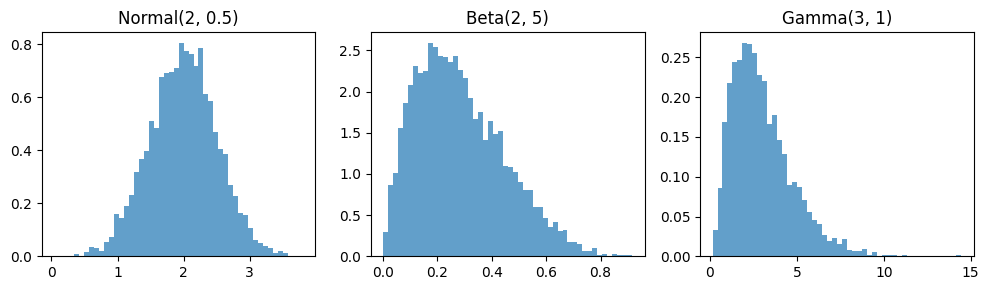

In [7]:
samples_n = jnp.asarray(sample(n, sample_shape=(5000,)))
samples_b = jnp.asarray(sample(b, sample_shape=(5000,)))
samples_g = jnp.asarray(sample(g, sample_shape=(5000,)))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, s, title in zip(axes, [samples_n, samples_b, samples_g],
                        ["Normal(2, 0.5)", "Beta(2, 5)", "Gamma(3, 1)"]):
    ax.hist(np.asarray(s), bins=50, density=True, alpha=0.7)
    ax.set_title(title)
plt.tight_layout(); plt.show()

Discrete distributions work the same way — a `Poisson` returns integer
counts, a `Categorical` returns class indices.

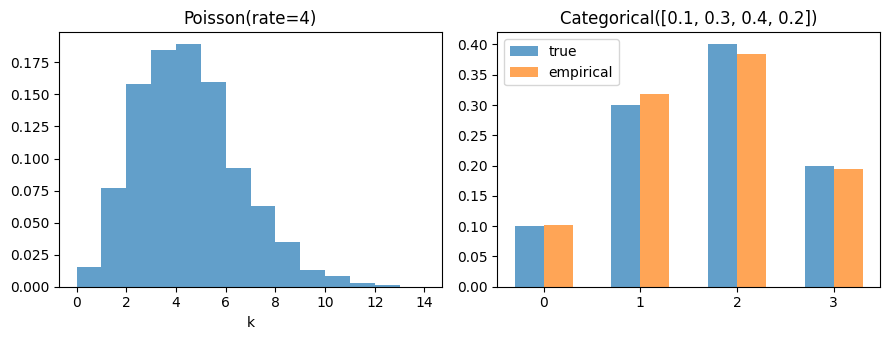

In [8]:
p = Poisson(rate=4.0, name="p")
cat = Categorical(probs=jnp.array([0.1, 0.3, 0.4, 0.2]), name="cat")
samples_p = jnp.asarray(sample(p, sample_shape=(1000,)))
samples_c = jnp.asarray(sample(cat, sample_shape=(1000,)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.hist(np.asarray(samples_p), bins=range(15), density=True, alpha=0.7)
ax1.set_title("Poisson(rate=4)"); ax1.set_xlabel("k")

classes = jnp.arange(4)
empirical = jnp.array([(samples_c == k).sum() for k in classes]) / 1000.0
ax2.bar(classes - 0.15, cat.probs, width=0.3, label="true", alpha=0.7)
ax2.bar(classes + 0.15, empirical, width=0.3, label="empirical", alpha=0.7)
ax2.set_xticks(classes); ax2.set_title("Categorical([0.1, 0.3, 0.4, 0.2])")
ax2.legend()
plt.tight_layout(); plt.show()

## 3. Density and probability

`log_prob(dist, x)` returns the log-density (for continuous distributions) or log-mass (for discrete ones), while `prob` returns its exponential. Pass an array of `x` values and you get an array of values back. 

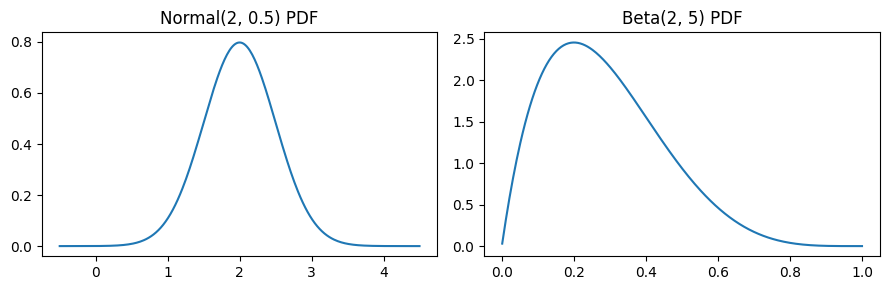

In [9]:
x = jnp.linspace(-0.5, 4.5, 300)
xb = jnp.linspace(0.001, 0.999, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(x, np.asarray(prob(n, x))); ax1.set_title("Normal(2, 0.5) PDF")
ax2.plot(xb, np.asarray(prob(b, xb))); ax2.set_title("Beta(2, 5) PDF")
plt.tight_layout(); plt.show()

## 4. Mean, variance, and covariance

`mean(dist)`, `variance(dist)`, and `cov(dist)` are the three moment ops. In general, `mean` is a vector, `variance` returns per-element variances (the diagonal of the full covariance), and `cov` returns the full covariance matrix.

In [10]:
# Scalar distributions: just mean and variance.
for dist in [n, b, g]:
    print(f"  {type(dist).__name__:8s} mean={float(mean(dist)):.4f}, "
          f"variance={float(variance(dist)):.4f}, "
          f"cov={float(cov(dist)):.4f}")

# Multivariate: mean is a vector, variance is per-element, cov is the matrix.
print(f"\nMultivariateNormal:")
print(f"  mean:     {jnp.asarray(mean(mvn))}")
print(f"  variance: {jnp.asarray(variance(mvn))}  (the diagonal of cov)")
print(f"  cov:\n{jnp.asarray(cov(mvn))}")

print(f"\nDirichlet:")
print(f"  mean:     {jnp.asarray(mean(d))}")
print(f"  variance: {jnp.asarray(variance(d))}")

  Normal   mean=2.0000, variance=0.2500, cov=0.2500
  Beta     mean=0.2857, variance=0.0255, cov=0.0255
  Gamma    mean=3.0000, variance=3.0000, cov=3.0000

MultivariateNormal:
  mean:     [ 1. -1.]


  variance: [1.        1.9999999]  (the diagonal of cov)
  cov:
[[1.        0.5      ]
 [0.5       1.9999999]]

Dirichlet:
  mean:     [0.25  0.625 0.125]


  variance: [0.02083333 0.02604167 0.01215278]


## 5. General expectations with `expectation`

For the expectation `E[f(X)]` of an arbitrary function `f`, use `expectation(dist, f)`. The result is exact when the distribution's support is finite; otherwise it defaults to a Monte Carlo estimate, returned by default as a `BootstrapDistribution` so you can check the MC sampling error. 

In [11]:
# MC estimate. The returned BootstrapDistribution carries the sampling error.
ex_sin = expectation(n, lambda x: jnp.sin(x))
print(f"E[sin(N(2, 0.5))] (MC, {ex_sin.n} draws):")
print(f"  point estimate:  {float(mean(ex_sin)):.4f}")
print(f"  MC std error:    {float(jnp.sqrt(variance(ex_sin))):.4f}")
print(f"  returned type:   {type(ex_sin).__name__}")

E[sin(N(2, 0.5))] (MC, 1024 draws):
  point estimate:  0.7899


  MC std error:    0.0075
  returned type:   BootstrapDistribution


If you don't want the MC sampling error tracked through, pass `return_dist=False` and `expectation` returns the point estimate directly:

In [12]:
# Turn off the error-bar wrapping with return_dist=False
ex_plain = expectation(n, lambda x: jnp.sin(x), return_dist=False)
print(f"E[sin(N(2, 0.5))] (return_dist=False):")
print(f"  point estimate:  {float(ex_plain):.4f}")
print(f"  returned type:   {type(ex_plain).__name__}")

E[sin(N(2, 0.5))] (return_dist=False):
  point estimate:  0.8142
  returned type:   NumericRecord


For finite-support distributions, `expectation` enumerates over the support and returns an exact value as a `NumericRecord`, rather than a `BootstrapDistribution`:

In [13]:
# Exact expectation on a finite-support distribution — no MC needed
ex_cat = expectation(cat, lambda x: x ** 2)
print(f"\nE[X^2] for Categorical([0.1, 0.3, 0.4, 0.2]) = {float(ex_cat):.3f}")
print(f"  by hand: 0*.1 + 1*.3 + 4*.4 + 9*.2 = {0*.1 + 1*.3 + 4*.4 + 9*.2:.3f}")
print(f"  returned type: {type(ex_cat).__name__}")


E[X^2] for Categorical([0.1, 0.3, 0.4, 0.2]) = 3.700
  by hand: 0*.1 + 1*.3 + 4*.4 + 9*.2 = 3.700
  returned type: NumericRecord


## 6. Converting between distributions with `from_distribution`

Not every distribution supports every operation. When you need an operation a source distribution doesn't have, the `from_distribution(source, TargetClass)` op bridges the gap. The converter registry picks a recipe for the `(source, target)` pair (KDE fit, moment matching, etc.) and returns a fresh `TargetClass` instance built from `source`.

Back to the empirical distribution from §1.3: it lacks `SupportsLogProb`, so calling `log_prob` directly raises a clear `TypeError`:

In [14]:
try:
    log_prob(empdist, jnp.array([0.0, 0.0]))
except TypeError as e:
    print(f"TypeError: {e}")

`from_distribution` bridges the gap. Converting the empirical sample to a `KDEDistribution` gives us a density estimate, and the converted distribution now satisfies `SupportsLogProb`:

In [15]:
kde = from_distribution(empdist, KDEDistribution, name="kde")
print(f"  type:                            {type(kde).__name__}")
print(f"  isinstance(kde, SupportsLogProb): {isinstance(kde, SupportsLogProb)}")
print(f"  log_prob at origin:              {float(log_prob(kde, jnp.array([0.0, 0.0]))):.4f}")

  type:                            KDEDistribution
  isinstance(kde, SupportsLogProb): True
  log_prob at origin:              -2.2566


The converter registry handles other useful conversions too — fitting a parametric family by moment matching, projecting through a `Bijector`, and more. See [Converting between representations](06_converting_representations.ipynb) for more details.